In [179]:
from numpy import pi

# Set to True to run on real IBM hardware, False to run locally on a noisy Aer simulator.
USE_HARDWARE = False

# Load IBM Quantum Compute Service
from qiskit_ibm_runtime import QiskitRuntimeService

# Syntax for first saving your token.  Delete these lines after saving your credentials.
# QiskitRuntimeService.save_account(channel='ibm_quantum_platform',
# instance = '<YOUR_IBM_INSTANCE_CRN>', token='<YOUR-API_KEY>', overwrite=True, set_as_default=True)
# service = QiskitRuntimeService(channel='ibm_quantum_platform')

# Load saved credentials
if USE_HARDWARE:
    service = QiskitRuntimeService()
else:
    service = None
    print("USE_HARDWARE = False -> local noisy Aer simulation")

USE_HARDWARE = False -> local noisy Aer simulation


In [180]:
if USE_HARDWARE:
    # Load the Runtime primitive and session
    from qiskit_ibm_runtime import (
        Batch,
        SamplerV2 as Sampler,
        EstimatorV2 as Estimator,
    )

    # Use the least busy backend
    backend = service.least_busy(min_num_qubits=127)

else:
    # Local stand-ins for the Runtime primitives, so that every cell below runs unchanged.
    from qiskit_ibm_runtime.fake_provider import FakeBrisbane
    from qiskit_aer import AerSimulator
    from qiskit_aer.noise import NoiseModel
    from qiskit.primitives import BackendSamplerV2, BackendEstimatorV2

    # A snapshot of the real ibm_brisbane device: 127 qubits, real basis gates,
    # real coupling map and real error rates.
    backend = FakeBrisbane()

    # Attach the device noise model by hand instead of using AerSimulator.from_backend():
    # that pins a strict target which rejects any gate outside the device basis, and a few
    # cells below run circuits that still hold ry/rx because they never went through the
    # pass manager.
    _sim = AerSimulator(noise_model=NoiseModel.from_backend(backend))

    # The Runtime primitives take mode=<backend|session|batch>; the local ones don't,
    # so these wrappers accept that argument and ignore it.
    class Sampler(BackendSamplerV2):
        def __init__(self, mode=None, **kwargs):
            super().__init__(backend=_sim, **kwargs)

    class Estimator(BackendEstimatorV2):
        def __init__(self, mode=None, **kwargs):
            super().__init__(backend=_sim, **kwargs)

    # There is nothing to batch locally - jobs run immediately.
    class Batch:
        def __init__(self, backend=None):
            pass

        def __enter__(self):
            return self

        def __exit__(self, *exc):
            return False

        def close(self):
            pass

print(backend.name)

fake_brisbane


In [181]:
# Import an estimator, this time from qiskit (we will import from Runtime for real hardware)
from qiskit_aer.primitives import SamplerV2, EstimatorV2
from qiskit_aer.noise import NoiseModel

# Generate the noise model from the backend properties
noise_model = NoiseModel.from_backend(backend)

noisy_sampler = SamplerV2(options={"backend_options": {"noise_model": noise_model}})
noisy_estimator = EstimatorV2(options={"backend_options": {"noise_model": noise_model}})

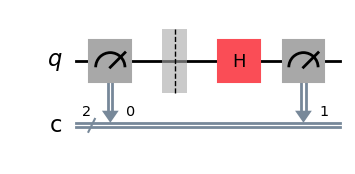

In [182]:
# Step 1: Map

# Import some general packages
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister

# Define registers
qr = QuantumRegister(1, "q")
cr = ClassicalRegister(2, "c")
qc = QuantumCircuit(qr, cr)

# Add a first measurement
qc.measure(qr, cr[0])
qc.barrier()

# Change basis so that measurements made on quantum computer which normally tell us about z,
# now tell us about x.
qc.h(qr)

# Add a second measurement
qc.measure(qr, cr[1])

qc.draw("mpl")

In [183]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc)

In [184]:
# Step 3: Run the job on a real quantum computer


sampler = Sampler(mode=backend)
pubs = [qc_isa]
job = sampler.run(pubs)
res = job.result()

counts = res[0].data.c.get_counts()

# Run the job on the Aer simulator with noise model from real backend

# job = noisy_sampler.run([qc_isa])
# res=job.result()
# counts=res[0].data.c.get_counts()

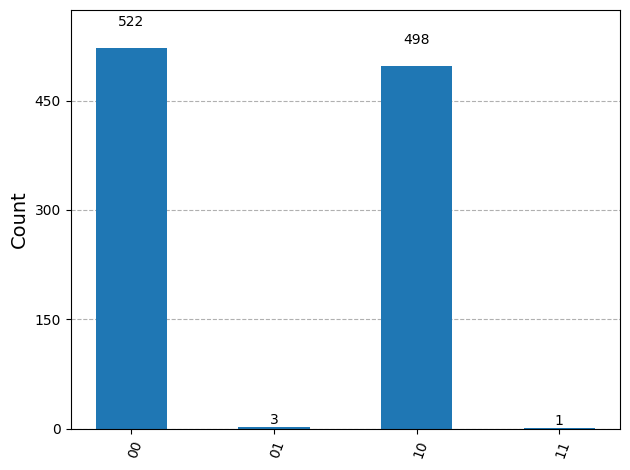

In [185]:
# Step 4: Post-process

from qiskit.visualization import plot_histogram

plot_histogram(counts)

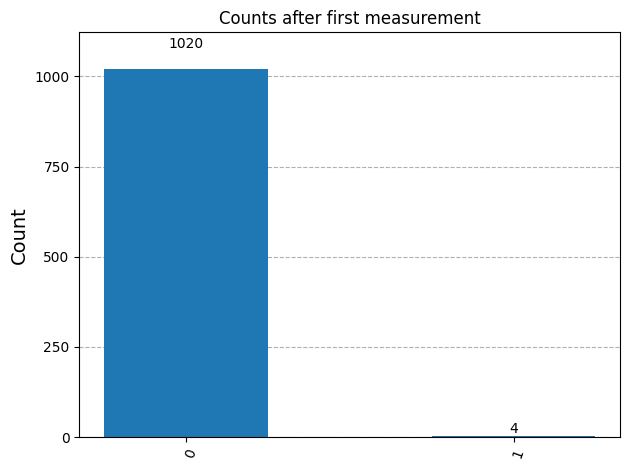

In [186]:
from qiskit.result import marginal_counts

plot_histogram(
    marginal_counts(counts, indices=[0]), title="Counts after first measurement"
)

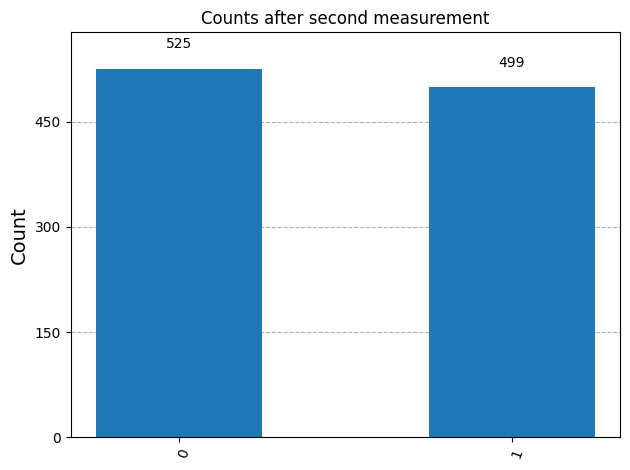

In [187]:
plot_histogram(
    marginal_counts(counts, indices=[1]), title="Counts after second measurement"
)

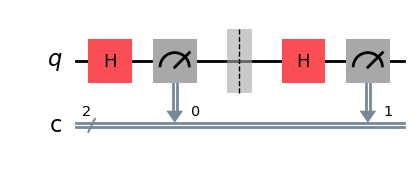

In [188]:
# Step 1:

# Define registers
qr = QuantumRegister(1, "q")
cr = ClassicalRegister(2, "c")
qc = QuantumCircuit(qr, cr)

# Change basis to measure along x.
qc.h(qr)
qc.measure(qr, cr[0])
qc.barrier()

# Change our basis back to z and make a second measurement
qc.h(qr)
qc.measure(qr, cr[1])

qc.draw("mpl")

In [189]:
# Step 2: Transpile the circuit for running on a quantum computer

pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

In [190]:
# Step 3: Run the job on a real quantum computer

sampler = Sampler(mode=backend)
pubs = [qc_isa]
job = sampler.run(pubs)
res = job.result()
counts = res[0].data.c.get_counts()

# Run the job on the Aer simulator with noise model from real backend
# job = noisy_sampler.run([qc_isa])
# res=job.result()
# counts=res[0].data.c.get_counts()

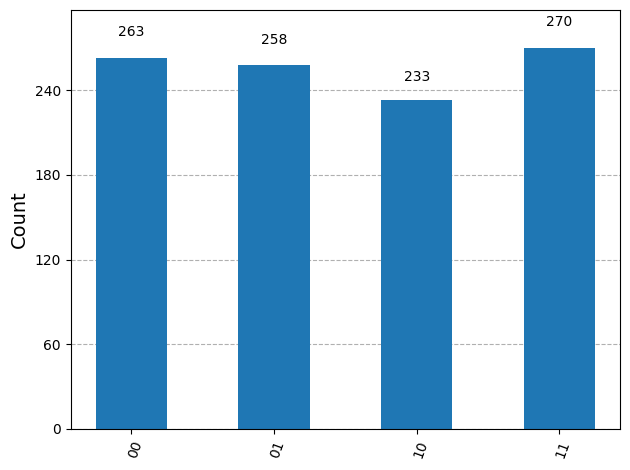

In [191]:
# Step 4: Post-process
from qiskit.visualization import plot_histogram

plot_histogram(counts)

In [192]:
# Step 1: Map the problem into a quantum circuit

from qiskit.quantum_info import SparsePauliOp
import numpy as np

obs = SparsePauliOp("X")

# Define registers
qr = QuantumRegister(1, "q")
cr = ClassicalRegister(1, "c")
qc = QuantumCircuit(qr, cr)

# Initialize the state
qc.initialize([1, 1j] / np.sqrt(2))

# Step 2: Transpile the circuit

pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
obs_isa = obs.apply_layout(layout=qc_isa.layout)

# Step 3: Run the circuit on a real quantum computer


estimator = Estimator(mode=backend)
pubs = [(qc_isa, obs_isa)]
job = estimator.run([[qc_isa, obs_isa]])
res = job.result()

# Run the job on the Aer simulator with noise model from real backend
# job = noisy_estimator.run([[qc_isa,obs_isa]])
# res=job.result()

# Step 4: Return the result in classical form, and analyze.

print(res[0].data.evs)

0.01904296875


In [193]:
# Step 1: Map the problem into a quantum circuit

obs = SparsePauliOp("Z")

# Define registers
qr = QuantumRegister(1, "q")
cr = ClassicalRegister(1, "c")
qc = QuantumCircuit(qr, cr)

# Initialize the state to |+>_y
qc.initialize([1, 1j] / np.sqrt(2))


# Step 2: Transpile the circuit

pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
obs_isa = obs.apply_layout(layout=qc_isa.layout)

# Step 3: Run the circuit on a real quantum computer

estimator = Estimator(mode=backend)
pubs = [(qc_isa, obs_isa)]
job = estimator.run(pubs)
res = job.result()

# Run the job on the Aer simulator with noise model from real backend
# job = noisy_estimator.run([[qc_isa,obs_isa]])
# res=job.result()

# Step 4: Return the result in classical form, and analyze.

print(res[0].data.evs)

-0.00537109375


In [194]:
# Step 1: Map the problem into a quantum circuit

obs1 = SparsePauliOp("X")
obs2 = SparsePauliOp("Z")

# Define registers

qr = QuantumRegister(1, "q")
cr = ClassicalRegister(1, "c")
qc = QuantumCircuit(qr, cr)

# Initialize the state
qc.initialize([1, 1] / np.sqrt(2))

# Step 2: Transpile the circuit

pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
obs1_isa = obs1.apply_layout(layout=qc_isa.layout)
obs2_isa = obs2.apply_layout(layout=qc_isa.layout)

# Step 3: Run the circuit on a real quantum computer

with Batch(backend=backend) as batch:
    estimator = Estimator(mode=batch)
    pubs = [(qc_isa, obs1_isa), (qc_isa, obs2_isa)]
    job = estimator.run(pubs)
    res = job.result()
batch.close()

# Run the job on the Aer simulator with noise model from real backend

# job = noisy_estimator.run([[qc,obs1],[qc,obs2]])
# res=job.result()

# Step 4: Return the result in classical form, and analyze.

print("The expectation value of the first observable is: ", res[0].data.evs)
print("The expectation value of the second observable is: ", res[1].data.evs)

The expectation value of the first observable is:  0.96044921875
The expectation value of the second observable is:  0.00634765625


In [195]:
obs1 = SparsePauliOp.from_list(
    [("X", 1.000)]
)
obs2 = SparsePauliOp.from_list(
    [("Y", 1.000)]
)
obs3 = SparsePauliOp.from_list(
    [("Z", 1.000)]
)
qc = QuantumCircuit(1,1)
qc.ry(pi/2,0)

job = estimator.run([(qc, [[obs1], [obs2], [obs3]])], precision=0.001)
res=job.result()

In [196]:
xs=res[0].data.evs[0]
ys=abs(res[0].data.evs[1])
zs=res[0].data.evs[2]

import math
prodxz=((1-xs[0]*xs[0])**0.5)*(1-zs[0]*zs[0])**0.5


In [197]:
obs1 = SparsePauliOp.from_list(
    [("X", 1.000)]
)
obs2 = SparsePauliOp.from_list(
    [("Y", 1.000)]
)
obs3 = SparsePauliOp.from_list(
    [("Z", 1.000)]
)
qc = QuantumCircuit(1,1)
qc.rx(-pi/2,0)

job = estimator.run([(qc, [[obs1], [obs2], [obs3]])], precision=0.001)
res=job.result()

In [198]:
xs=res[0].data.evs[0]
ys=abs(res[0].data.evs[1])
zs=res[0].data.evs[2]

import math
prodxz=((1-xs[0]*xs[0])**0.5)*(1-zs[0]*zs[0])**0.5


In [169]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer.primitives import EstimatorV2

# 1. 테스트할 상태(Circuit) 준비
circuits = {
    "|0>": QuantumCircuit(1),  # 기본 초기 상태 |0>
    "|1>": QuantumCircuit(1),  # X 게이트로 만든 |1>
    "|+>": QuantumCircuit(1),  # H 게이트로 만든 |+>
    "|->": QuantumCircuit(1)   # X, H 게이트로 만든 |->
}
circuits["|1>"].x(0)
circuits["|+>"].h(0)
circuits["|->"].x(0)
circuits["|->"].h(0)

# 2. 파울리 관측량(Observables) 정의
obs_X = SparsePauliOp("X")
obs_Y = SparsePauliOp("Y")
obs_Z = SparsePauliOp("Z")

# 3. Estimator 실행
estimator = EstimatorV2()

print(f"{'State':<8} | {'ΔX':<8} | {'ΔZ':<8} | {'ΔX*ΔZ':<8} | {'|<Y>|':<8} | {'Valid?'}")
print("-" * 60)

for name, qc in circuits.items():
    # X, Y, Z 각각의 기댓값 계산 요청 PUBs
    pubs = [(qc, obs_X), (qc, obs_Y), (qc, obs_Z)]
    job = estimator.run(pubs)
    results = job.result()
    
    # 기댓값 <X>, <Y>, <Z> 추출
    ev_X = float(results[0].data.evs)
    ev_Y = float(results[1].data.evs)
    ev_Z = float(results[2].data.evs)
    
    # 분산 ΔA = sqrt(1 - <A>^2) 계산
    delta_X = np.sqrt(max(0, 1 - ev_X**2))
    delta_Z = np.sqrt(max(0, 1 - ev_Z**2))
    
    product = delta_X * delta_Z
    abs_Y = abs(ev_Y)
    
    # 부등식 ΔX * ΔZ >= |<Y>| 검증
    is_valid = product >= abs_Y - 1e-5  # 부동소수점 오차 감안
    
    print(f"{name:<8} | {delta_X:<8.3f} | {delta_Z:<8.3f} | {product:<8.3f} | {abs_Y:<8.3f} | {is_valid}")

State    | ΔX       | ΔZ       | ΔX*ΔZ    | |<Y>|    | Valid?
------------------------------------------------------------
|0>      | 1.000    | 0.000    | 0.000    | 0.000    | True
|1>      | 1.000    | 0.000    | 0.000    | 0.000    | True
|+>      | 0.000    | 1.000    | 0.000    | 0.000    | True
|->      | 0.000    | 1.000    | 0.000    | 0.000    | True


In [170]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer.primitives import EstimatorV2

# 1. Y축 고유상태 (+i, -i) 회로 생성
# |+i> = H -> S 연산 적용
qc_plus_i = QuantumCircuit(1)
qc_plus_i.h(0)
qc_plus_i.s(0)

# |-i> = X -> H -> S 연산 적용
qc_minus_i = QuantumCircuit(1)
qc_minus_i.x(0)
qc_minus_i.h(0)
qc_minus_i.s(0)

circuits = {
    "|+i>": qc_plus_i,
    "|-i>": qc_minus_i
}

# 2. 파울리 관측량 정의
obs_X = SparsePauliOp("X")
obs_Y = SparsePauliOp("Y")
obs_Z = SparsePauliOp("Z")

# 3. Estimator 실행
estimator = EstimatorV2()

print(f"{'State':<8} | {'ΔX':<8} | {'ΔZ':<8} | {'ΔX*ΔZ':<8} | {'|<Y>|':<8} | {'Valid?'}")
print("-" * 60)

for name, qc in circuits.items():
    pubs = [(qc, obs_X), (qc, obs_Y), (qc, obs_Z)]
    job = estimator.run(pubs)
    results = job.result()
    
    # 기댓값 추출
    ev_X = float(results[0].data.evs)
    ev_Y = float(results[1].data.evs)
    ev_Z = float(results[2].data.evs)
    
    # 불확정성(분산) ΔA = sqrt(1 - <A>^2) 계산
    delta_X = np.sqrt(max(0, 1 - ev_X**2))
    delta_Z = np.sqrt(max(0, 1 - ev_Z**2))
    
    product = delta_X * delta_Z
    abs_Y = abs(ev_Y)
    
    # ΔX * ΔZ >= |<Y>| 성립 여부 확인
    is_valid = product >= abs_Y - 1e-5
    
    print(f"{name:<8} | {delta_X:<8.3f} | {delta_Z:<8.3f} | {product:<8.3f} | {abs_Y:<8.3f} | {is_valid}")

State    | ΔX       | ΔZ       | ΔX*ΔZ    | |<Y>|    | Valid?
------------------------------------------------------------
|+i>     | 1.000    | 1.000    | 1.000    | 1.000    | True
|-i>     | 1.000    | 1.000    | 1.000    | 1.000    | True


In [171]:
"""▶TESTING UNCERTAINTY RELATIONS◀"""

'▶TESTING UNCERTAINTY RELATIONS◀'

In [199]:
# The calculation below uses approximately 3-4 minutes of QPU time.
# Step 1: Map the problem into a quantum circuit

from qiskit.circuit import Parameter
import numpy as np

# Specify observables
obs1 = SparsePauliOp("X")
obs2 = SparsePauliOp("Y")
obs3 = SparsePauliOp("Z")

# Define registers
qr = QuantumRegister(1, "q")
cr = ClassicalRegister(1, "c")
qc = QuantumCircuit(qr, cr)

# Rotate away from |0>
theta = Parameter("θ")
qc.ry(theta, 0)

params = np.linspace(0, 2, num=21)

# Step 2: Transpile the circuit

pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
obs1_isa = obs1.apply_layout(layout=qc_isa.layout)
obs2_isa = obs2.apply_layout(layout=qc_isa.layout)
obs3_isa = obs3.apply_layout(layout=qc_isa.layout)

# Step 3: Run the circuit on a real quantum computer

with Batch(backend=backend) as batch:
    estimator = Estimator(mode=batch)
    pubs = [(qc_isa, [[obs1_isa], [obs2_isa], [obs3_isa]], [params])]
    job = estimator.run(pubs, precision=0.01)
    res = job.result()

batch.close()

# Run the job on the Aer simulator with noise model from real backend

# job = noisy_estimator.run([(qc, [[obs1], [obs2], [obs3]], [params])])
# res=job.result()

In [200]:
# Step 4: Post-processing and classical analysis.
xs = res[0].data.evs[0]
ys = abs(res[0].data.evs[1])
zs = res[0].data.evs[2]

# Calculate uncertainties

delx = []
delz = []
prodxz = []
for i in range(len(xs)):
    delx.append(abs((1 - xs[i] * xs[i])) ** 0.5)
    delz.append(abs((1 - zs[i] * zs[i])) ** 0.5)
    prodxz.append(delx[i] * delz[i])

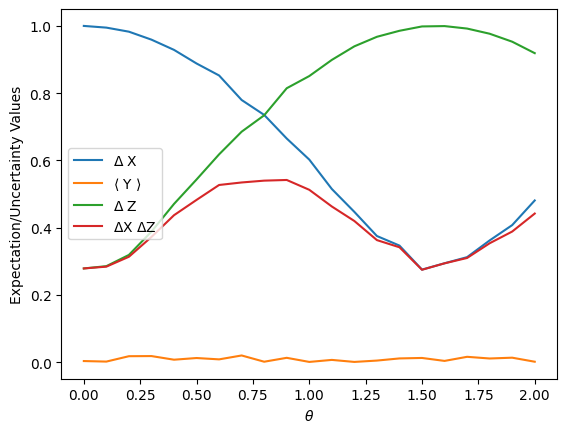

In [201]:
# Here we can plot the results from this simulation.
import matplotlib.pyplot as plt

plt.plot(params, delx, label=r"$\Delta$ X")
plt.plot(params, ys, label=r"$\langle$ Y $\rangle$")
plt.plot(params, delz, label=r"$\Delta$ Z")
plt.plot(params, prodxz, label=r"$\Delta$X $\Delta$Z")
plt.xlabel(r"$\theta$")
plt.ylabel("Expectation/Uncertainty Values")
plt.legend()
plt.show()

In [202]:
# The calculation below uses approximately 3-4 minutes of QPU time.
from qiskit.circuit import Parameter
import numpy as np

# Step 1: Map the problem to a quantum circuit

# Specify observables
obs1 = SparsePauliOp("X")
obs2 = SparsePauliOp("Y")
obs3 = SparsePauliOp("Z")

# Define registers
qr = QuantumRegister(1, "q")
cr = ClassicalRegister(1, "c")
qc = QuantumCircuit(qr, cr)

# Rotate away from |0> along one plane, and then along a transverse direction.
theta = Parameter("θ")
qc.ry(theta, 0)
qc.rz(pi / 4, 0)

params = np.linspace(0, 2, num=21)

# Step 2: Transpile the circuit

pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

obs1_isa = obs1.apply_layout(layout=qc_isa.layout)
obs2_isa = obs2.apply_layout(layout=qc_isa.layout)
obs3_isa = obs3.apply_layout(layout=qc_isa.layout)

# Step 3: Run the circuit on a real quantum computer

with Batch(backend=backend) as batch:
    estimator = Estimator(mode=batch)
    pubs = [(qc_isa, [[obs1_isa], [obs2_isa], [obs3_isa]], [params])]
    job = estimator.run(pubs, precision=0.01)
    res = job.result()

batch.close()

# Run the job on the Aer simulator with noise model from real backend

# job = noisy_estimator.run([(qc, [[obs1], [obs2], [obs3]], [params])])
# res=job.result()

In [203]:
# Step 4: Post-processing and classical analysis.
xs = res[0].data.evs[0]
ys = abs(res[0].data.evs[1])
zs = res[0].data.evs[2]

# Calculate uncertainties

delx = []
delz = []
prodxz = []
for i in range(len(xs)):
    delx.append(abs((1 - xs[i] * xs[i])) ** 0.5)
    delz.append(abs((1 - zs[i] * zs[i])) ** 0.5)
    prodxz.append(delx[i] * delz[i])

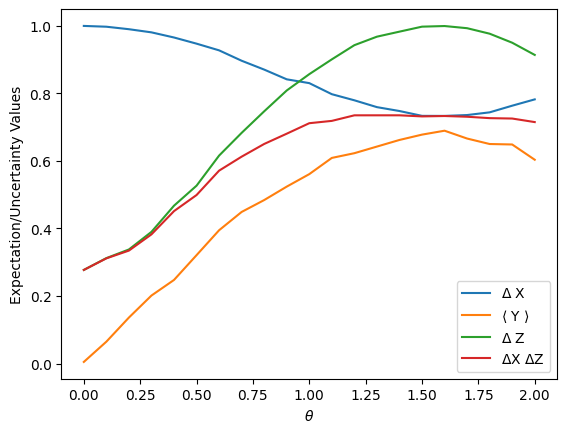

In [204]:
# Here we can plot the results from this simulation.
import matplotlib.pyplot as plt

plt.plot(params, delx, label=r"$\Delta$ X")
plt.plot(params, ys, label=r"$\langle$ Y $\rangle$")
plt.plot(params, delz, label=r"$\Delta$ Z")
plt.plot(params, prodxz, label=r"$\Delta$X $\Delta$Z")
plt.xlabel(r"$\theta$")
plt.ylabel("Expectation/Uncertainty Values")
plt.legend()
plt.show()